# Statistical Tests

In [45]:
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

In [5]:
PROJECT_ROOT = Path.cwd().parent   # assumes notebook lives in notebooks/, project root is one level up
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DATA_PATH = DATA_DIR / "customer_personality_cleaned.csv"

In [6]:
df = pd.read_csv(RAW_DATA_PATH)

In [7]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'age', 'Accepted_Cmp', 'duration', 'children',
       'HighestPurchaseSource'],
      dtype='object')

In [20]:
categorical_cols = ["Education", "Marital_Status", "Complain", "HighestPurchaseSource"]
target_col = "Accepted_Cmp"

### Chi_Square test

In [57]:
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    print({"variable": col, "test": "chi_square", "statistic": chi2, "p_value": p})

{'variable': 'Education', 'test': 'chi_square', 'statistic': 15.07498774890878, 'p_value': 0.004548188000236728}
{'variable': 'Marital_Status', 'test': 'chi_square', 'statistic': 10.08966064828287, 'p_value': 0.03894414225936596}
{'variable': 'Complain', 'test': 'chi_square', 'statistic': 0.9776213771050242, 'p_value': 0.3227867562057984}
{'variable': 'HighestPurchaseSource', 'test': 'chi_square', 'statistic': 87.62630236992018, 'p_value': 9.379727157615506e-20}


### Anova Test 

In [28]:
numeric_cols = ['Income', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'age', 'duration', 'children']

In [59]:
anova_results = []
for col in numeric_cols:
    groups = [group[col].values for _, group in df.groupby(target_col, observed=True)]
    f_stat, p = stats.f_oneway(*groups)
    anova_results.append({"variable": col, "test": "one-way ANOVA", "statistic": f_stat, "p_value": p})

anova_df = pd.DataFrame(anova_results)
anova_df

,variable,test,statistic,p_value
0,Income,one-way ANOVA,184.988837,1.609019e-40
1,MntWines,one-way ANOVA,477.223690,5.981678e-96
2,MntFruits,one-way ANOVA,44.422892,3.330418e-11
3,MntMeatProducts,one-way ANOVA,207.144664,5.823456e-45
4,MntFishProducts,one-way ANOVA,57.808271,4.243839e-14
5,MntSweetProducts,one-way ANOVA,61.047018,8.545373e-15
6,MntGoldProds,one-way ANOVA,84.338198,9.311220e-20
7,NumDealsPurchases,one-way ANOVA,2.369382,1.238792e-01
8,NumWebPurchases,one-way ANOVA,113.339910,7.597711e-26
9,NumCatalogPurchases,one-way ANOVA,227.354685,5.638676e-49


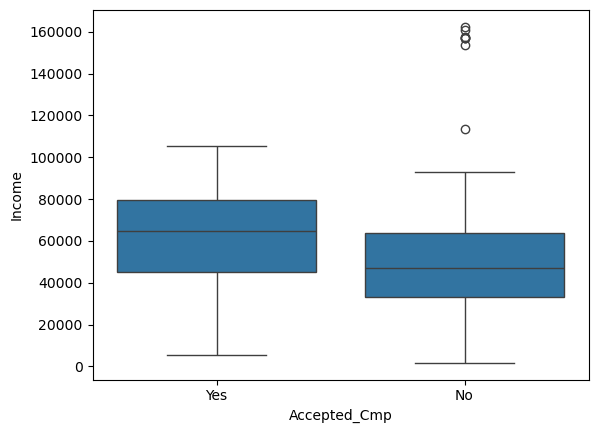

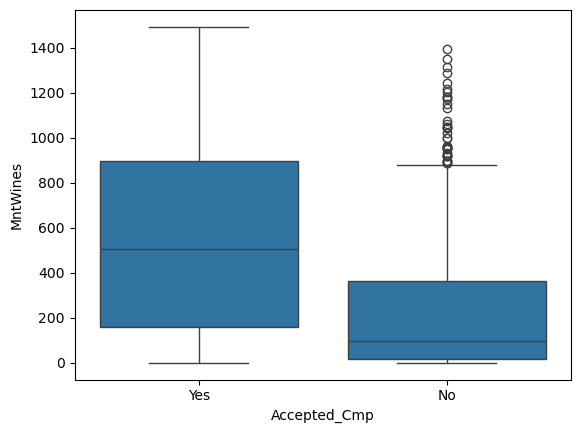

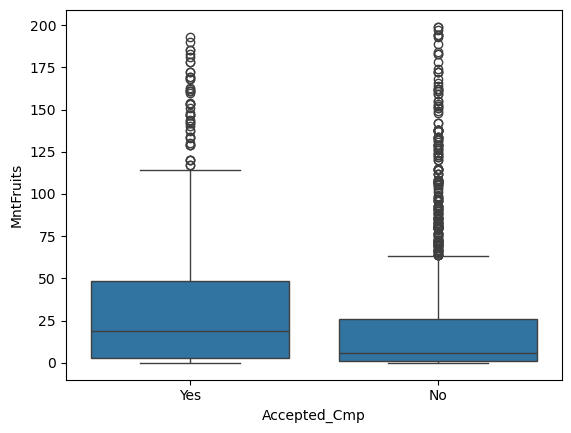

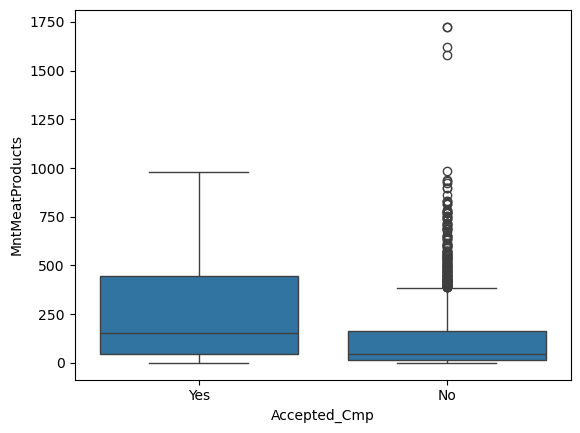

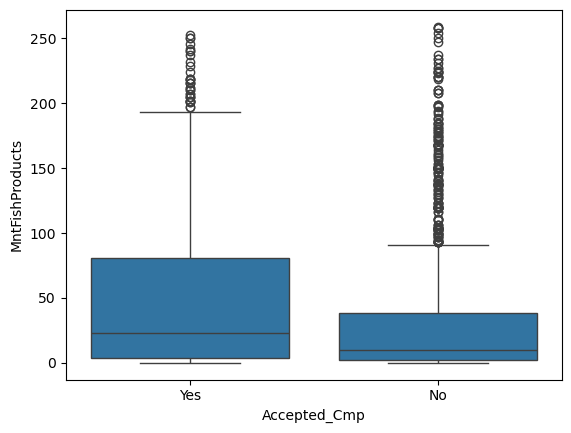

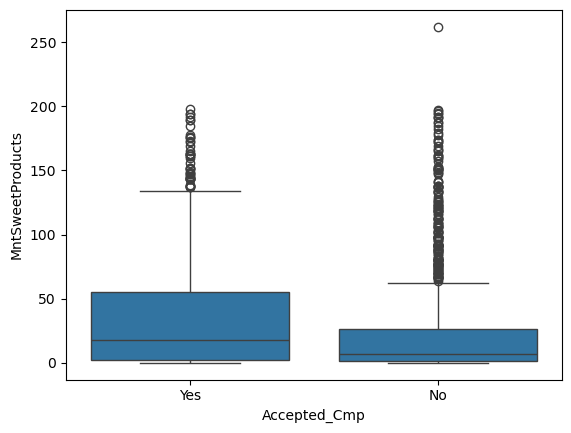

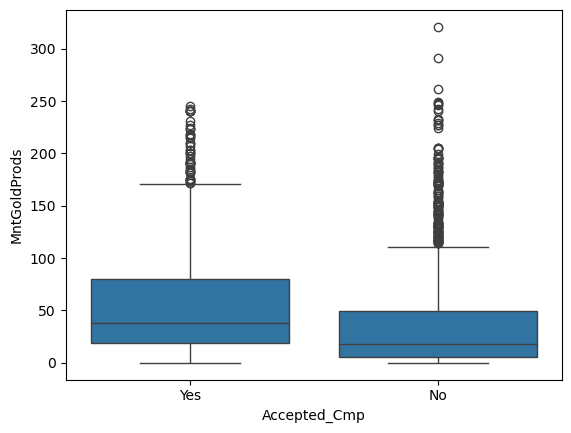

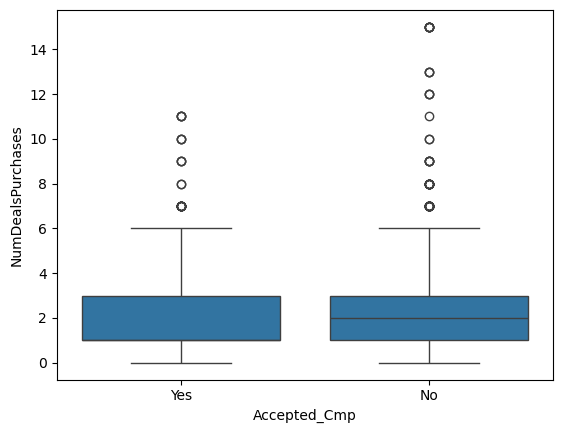

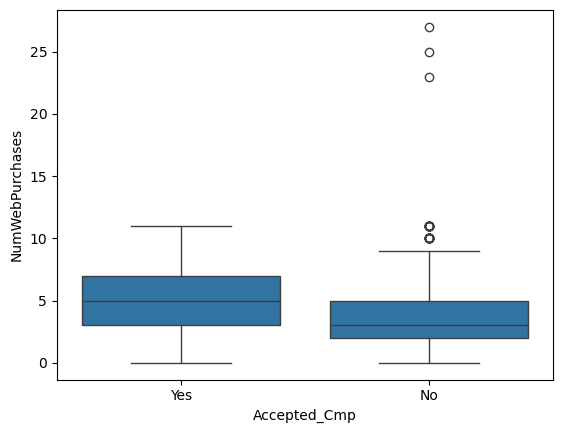

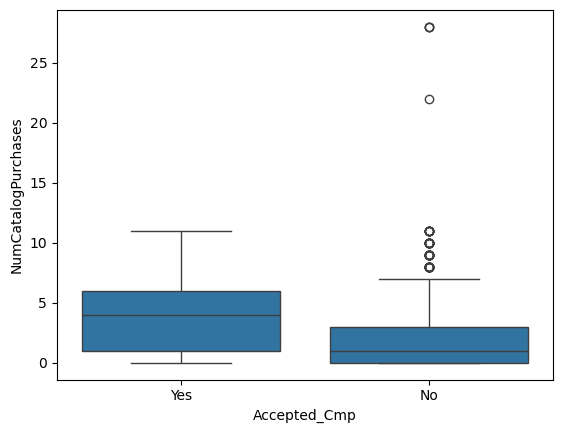

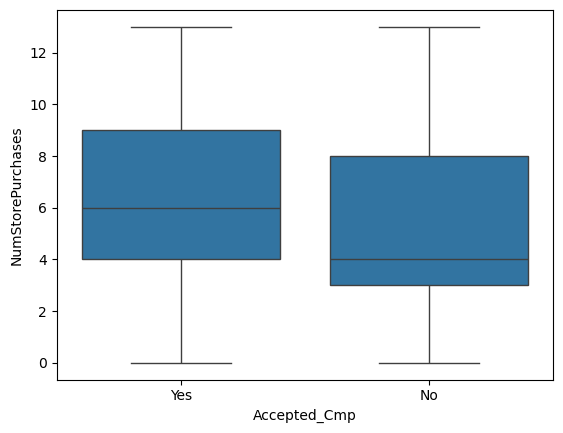

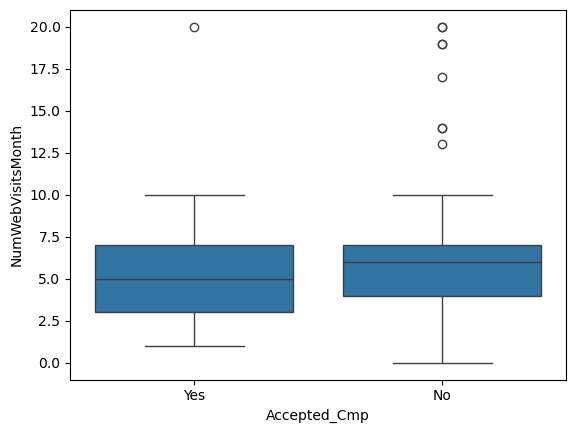

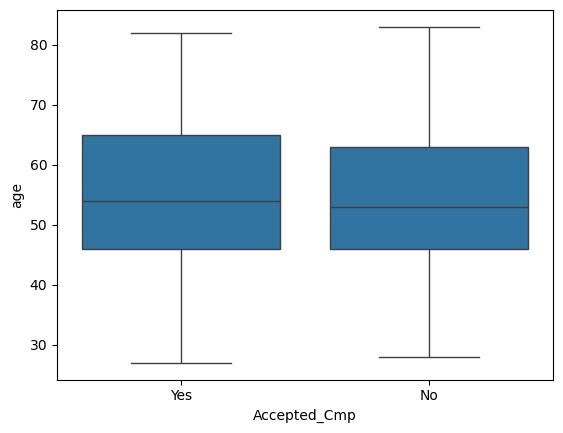

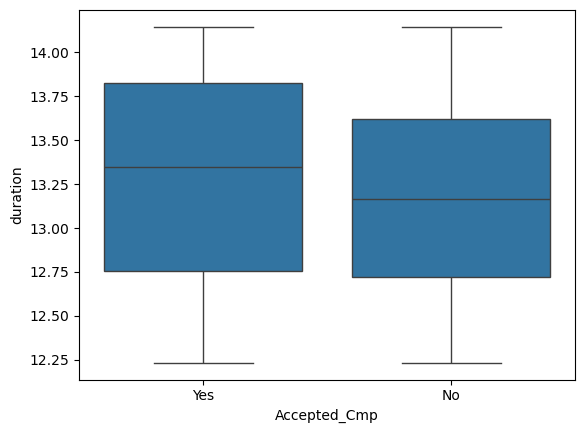

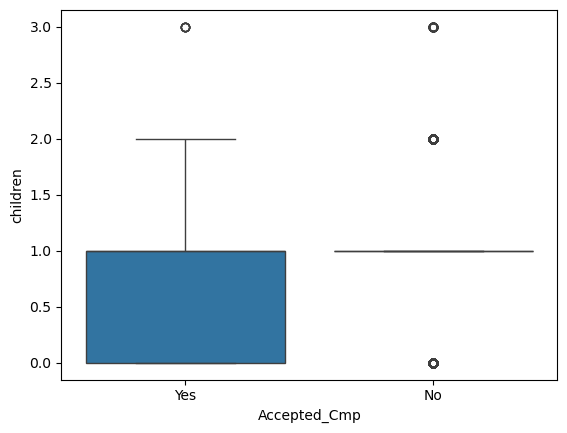

In [64]:
import seaborn as sns
for col in numeric_cols:
    sns.boxplot(data=df, x=target_col, y=col)
    plt.show()